### Environment
- Python 2.7
- apache Spark 2.3.0   
- apache Cassandra 3.11.16

In [21]:
!/usr/local/cassandra/bin/cqlsh -e "SELECT release_version FROM system.local;"


 release_version
-----------------
         3.11.16

(1 rows)


In [1]:
from pyspark.sql import SparkSession


spark=SparkSession.builder\
    .appName("MovieLens-Cassandra")\
    .config("spark.cassandra.connection.host", "localhost") \
    .config("spark.cassandra.connection.port", "9042") \
    .master("local[*]") \
    .getOrCreate()
spark

## Step 1: Load data from HDFS
First,upload three files to HDFS at /user/maria_dev/ml-100k/
```
hdfs dfs -mkdir -p /user/maria_dev/ml-100k
hdfs dfs -put u.data /user/maria_dev/ml-100k/
hdfs dfs -put u.item /user/maria_dev/ml-100k/
hdfs dfs -put u.user /user/maria_dev/ml-100k/
```
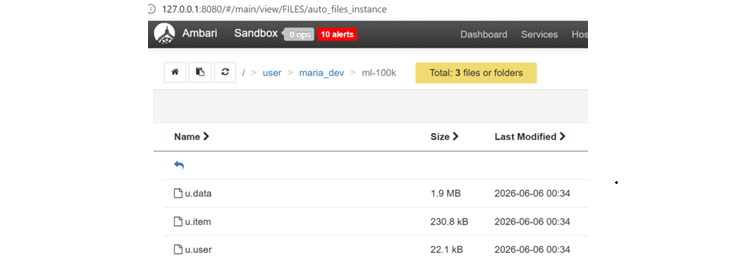

Then we read each file as an RDD

In [2]:
# load data
r_rdd = spark.sparkContext.textFile("hdfs:///user/maria_dev/ml-100k/u.data")
u_rdd = spark.sparkContext.textFile("hdfs:///user/maria_dev/ml-100k/u.user")
m_rdd = spark.sparkContext.textFile("hdfs:///user/maria_dev/ml-100k/u.item")

# row count
print(r_rdd.count(),u_rdd.count(),m_rdd.count())


(100000, 943, 1682)


## Step 2: RDD convert to dataframe

Each RDD line is mapped to a dataframe.

In [3]:
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, FloatType, LongType

#rating dataframe
r_schema=StructType([
    StructField("user_id", IntegerType()),
    StructField("movie_id", IntegerType()),
    StructField("rating", FloatType()),
    StructField("timestamp", LongType())
])
r_parsed= r_rdd.map(lambda x: x.split("\t"))

rating_df= spark.createDataFrame( r_parsed.map(lambda x:(int(x[0]),int(x[1]),float(x[2]),int(x[3]))),
    schema=r_schema
)

#user df
u_schema = StructType([
    StructField("user_id", IntegerType()),
    StructField("age", IntegerType()),
    StructField("gender", StringType()),
    StructField("occupation", StringType()),
    StructField("zip_code", StringType())
])
u_parsed = u_rdd.map(lambda x: x.split("|"))
user_df = spark.createDataFrame( u_parsed.map(lambda x: (int(x[0]), int(x[1]), x[2], x[3], x[4])),
    schema=u_schema)

#movie df
m_parsed=m_rdd.map(lambda x: x.split("|"))
movie_df=spark.createDataFrame(
    m_parsed.map(lambda x: (int(x[0]), x[1], ",".join(x[5:24]))),
schema=StructType([
        StructField("movie_id", IntegerType()),
        StructField("title", StringType()),
        StructField("genres", StringType())
    ])
)

rating_df.show(3)
user_df.show(3)
movie_df.show(5)


+-------+--------+------+---------+
|user_id|movie_id|rating|timestamp|
+-------+--------+------+---------+
|    196|     242|   3.0|881250949|
|    186|     302|   3.0|891717742|
|     22|     377|   1.0|878887116|
+-------+--------+------+---------+
only showing top 3 rows

+-------+---+------+----------+--------+
|user_id|age|gender|occupation|zip_code|
+-------+---+------+----------+--------+
|      1| 24|     M|technician|   85711|
|      2| 53|     F|     other|   94043|
|      3| 23|     M|    writer|   32067|
+-------+---+------+----------+--------+
only showing top 3 rows

+--------+-----------------+--------------------+
|movie_id|            title|              genres|
+--------+-----------------+--------------------+
|       1| Toy Story (1995)|0,0,0,1,1,1,0,0,0...|
|       2| GoldenEye (1995)|0,1,1,0,0,0,0,0,0...|
|       3|Four Rooms (1995)|0,0,0,0,0,0,0,0,0...|
|       4|Get Shorty (1995)|0,1,0,0,0,1,0,0,1...|
|       5|   Copycat (1995)|0,0,0,0,0,0,1,0,1...|
+--------+-

## Step 3: Data cleaning and validation

Check:
- Null values
- Rating range validation

In [4]:
from pyspark.sql.functions import col, count, when

r_cnt=rating_df.count()
u_cnt=user_df.count()
m_cnt=movie_df.count()
print("ratings:",r_cnt,"user:",u_cnt,"movie:",m_cnt)

rating_df.select([count(when(col(c).isNull(), c)).alias(c) for c in rating_df.columns]).show()
rating_df.describe("rating").show()

abnormal = rating_df.filter((col("rating")<1)|(col("rating")> 5)).count()
print("abnormal ratings count:",abnormal)


('ratings:', 100000, 'user:', 943, 'movie:', 1682)
+-------+--------+------+---------+
|user_id|movie_id|rating|timestamp|
+-------+--------+------+---------+
|      0|       0|     0|        0|
+-------+--------+------+---------+

+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|            100000|
|   mean|           3.52986|
| stddev|1.1256735991443179|
|    min|               1.0|
|    max|               5.0|
+-------+------------------+

('abnormal ratings count:', 0)


## Step 4:  Analytical tasks



### Task i:  Average rating per movie
Group ratings by movie_id

In [5]:
from pyspark.sql.functions import avg

avg_r=rating_df.groupBy("movie_id").agg(
    avg("rating").alias("avg_rating"),
    count("rating").alias("rating_count")
)

result1 = avg_r.join(movie_df.select("movie_id", "title"), on="movie_id") \
    .select("movie_id", "title", "avg_rating", "rating_count")

result1.show(10)


+--------+--------------------+------------------+------------+
|movie_id|               title|        avg_rating|rating_count|
+--------+--------------------+------------------+------------+
|     148|Ghost and the Dar...|          3.203125|         128|
|     463|Secret of Roan In...| 3.859154929577465|          71|
|     471|Courage Under Fir...|3.6108597285067874|         221|
|     496|It's a Wonderful ...| 4.121212121212121|         231|
|     833|  Bulletproof (1996)| 3.204081632653061|          49|
|    1088|  Double Team (1997)| 2.230769230769231|          13|
|    1238|   Full Speed (1996)|             3.125|           8|
|    1342|Convent, The (Con...|               2.5|           2|
|    1580|     Liebelei (1933)|               1.0|           1|
|    1591|Duoluo tianshi (1...|3.1666666666666665|           6|
+--------+--------------------+------------------+------------+
only showing top 10 rows



### Task ii: Top 10 Movies by average rating


In [6]:
from pyspark.sql.functions import desc

result2 = result1.orderBy(desc("avg_rating")).limit(10)
result2.show(10, truncate=False)


+--------+-------------------------------------------------+----------+------------+
|movie_id|title                                            |avg_rating|rating_count|
+--------+-------------------------------------------------+----------+------------+
|1599    |Someone Else's America (1995)                    |5.0       |1           |
|1293    |Star Kid (1997)                                  |5.0       |3           |
|1653    |Entertaining Angels: The Dorothy Day Story (1996)|5.0       |1           |
|1201    |Marlene Dietrich: Shadow and Light (1996)        |5.0       |1           |
|1189    |Prefontaine (1997)                               |5.0       |3           |
|1467    |Saint of Fort Washington, The (1993)             |5.0       |2           |
|1122    |They Made Me a Criminal (1939)                   |5.0       |1           |
|1500    |Santa with Muscles (1996)                        |5.0       |2           |
|1536    |Aiqing wansui (1994)                             |5.0  

### Task iii: Active Users (>50 rating) and their favorite genre

Steps:
1. Filter users with at least 50 ratings
2. Join their ratings with movie genre tags
3. Count ratings per user per genre
4. Select the genre with the highest count for each user

In [7]:
from pyspark.sql.functions import explode, split, lit, array, posexplode, row_number, trim
from pyspark.sql.window import Window
# parse genres from original string
genre_str = " | unknown | Action | Adventure | Animation | Children's | Comedy | Crime | Documentary | Drama | Fantasy | Film-Noir | Horror | Musical | Mystery | Romance | Sci-Fi | Thriller | War | Western |"

genre_names = [x.strip() for x in genre_str.split("|") if x.strip()]
movies_genre = movie_df.select("movie_id", posexplode(split("genres", ",")).alias("genre_idx", "flag")).filter(col("flag") == "1").select("movie_id", "genre_idx")
print(genre_names)

['unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [8]:
active_users = rating_df.groupBy("user_id").agg(count("rating").alias("total_ratings")) \
    .filter(col("total_ratings") >= 50)

active_ratings = rating_df.join(active_users.select("user_id"), on="user_id")

ratings_genre = active_ratings.join(movies_genre, on="movie_id")

user_genre_cnt = ratings_genre.groupBy("user_id", "genre_idx").agg(count("*").alias("genre_count"))


w = Window.partitionBy("user_id").orderBy(desc("genre_count"))
result3 = user_genre_cnt.withColumn("rank", row_number().over(w)) \
    .filter(col("rank") == 1) \
    .withColumn("favorite_genre", array([lit(name) for name in genre_names])[col("genre_idx")]) \
    .select("user_id", "favorite_genre", "genre_count")
result3.show(10)

+-------+--------------+-----------+
|user_id|favorite_genre|genre_count|
+-------+--------------+-----------+
|    148|         Drama|         25|
|    463|         Drama|         59|
|    496|         Drama|         52|
|    833|         Drama|         97|
|    243|         Drama|         59|
|    392|         Drama|         57|
|    540|         Drama|         28|
|    897|        Action|         57|
|     85|         Drama|        152|
|    251|        Action|         31|
+-------+--------------+-----------+
only showing top 10 rows



### Task iv: Users under 20 years old

In [18]:
result4 = user_df.filter(col("age") < 20)
result4.show(15)
print("count:",result4.count())


+-------+---+------+-------------+--------+
|user_id|age|gender|   occupation|zip_code|
+-------+---+------+-------------+--------+
|     30|  7|     M|      student|   55436|
|     36| 19|     F|      student|   93117|
|     52| 18|     F|      student|   55105|
|     57| 16|     M|         none|   84010|
|     67| 17|     M|      student|   60402|
|     68| 19|     M|      student|   22904|
|    101| 15|     M|      student|   05146|
|    110| 19|     M|      student|   77840|
|    142| 13|     M|        other|   48118|
|    179| 15|     M|entertainment|   20755|
|    206| 14|     F|      student|   53115|
|    221| 19|     M|      student|   20685|
|    223| 19|     F|      student|   47906|
|    246| 19|     M|      student|   28734|
|    257| 17|     M|      student|   77005|
+-------+---+------+-------------+--------+
only showing top 15 rows

('count:', 77)


### Task v: scientists age between 30-40


In [10]:
res5 = user_df.filter(
    (col("occupation") == "scientist") &
    (col("age") >= 30) &
    (col("age") <= 40)
)
res5.show()
print("Count:", res5.count())


+-------+---+------+----------+--------+
|user_id|age|gender|occupation|zip_code|
+-------+---+------+----------+--------+
|     40| 38|     M| scientist|   27514|
|     71| 39|     M| scientist|   98034|
|     74| 39|     M| scientist|   T8H1N|
|    107| 39|     M| scientist|   60466|
|    183| 33|     M| scientist|   27708|
|    272| 33|     M| scientist|   53706|
|    309| 40|     M| scientist|   70802|
|    337| 37|     M| scientist|   10522|
|    430| 38|     M| scientist|   98199|
|    538| 31|     M| scientist|   21010|
|    543| 33|     M| scientist|   95123|
|    554| 32|     M| scientist|   62901|
|    643| 39|     M| scientist|   55122|
|    730| 31|     F| scientist|   32114|
|    874| 36|     M| scientist|   37076|
|    918| 40|     M| scientist|   70116|
+-------+---+------+----------+--------+

('Count:', 16)


## Step 5: Write Results to Cassandra

Keyspace: movie_len

Table: "results", include movie_id,title,avg_rating,rating_count

The Task i result1 are write into Cassandra

Here is my CQL command in ssh terminal:
```sql
CREATE KEYSPACE movie_analysis
WITH replication = {'class': 'SimpleStrategy', 'replication_factor': 1};
USE movie_analysis;
CREATE TABLE results (
    movie_id INT PRIMARY KEY,
    title TEXT,
    avg_rating FLOAT,
    rating_count INT
);
DESC TABLES;
```

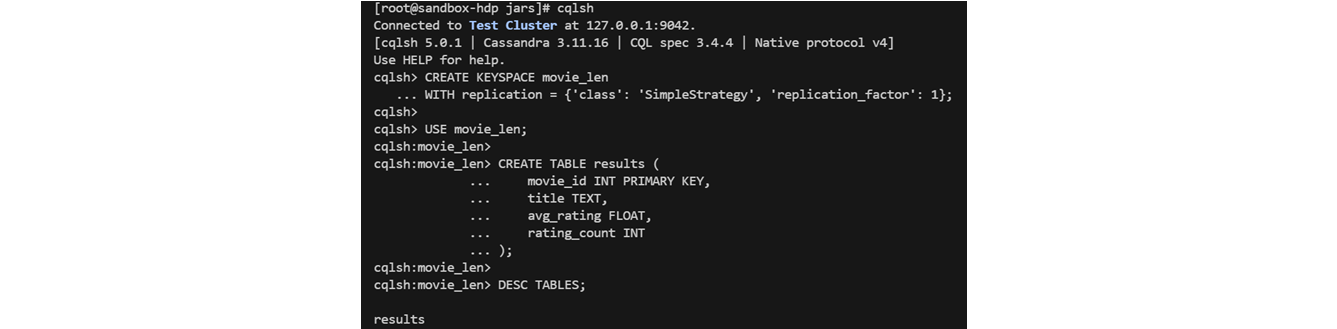

In [12]:
result1

DataFrame[movie_id: int, title: string, avg_rating: double, rating_count: bigint]

In [13]:
result1.write \
    .format("org.apache.spark.sql.cassandra") \
    .options(table="results", keyspace="movie_len") \
    .mode("append") \
    .save()


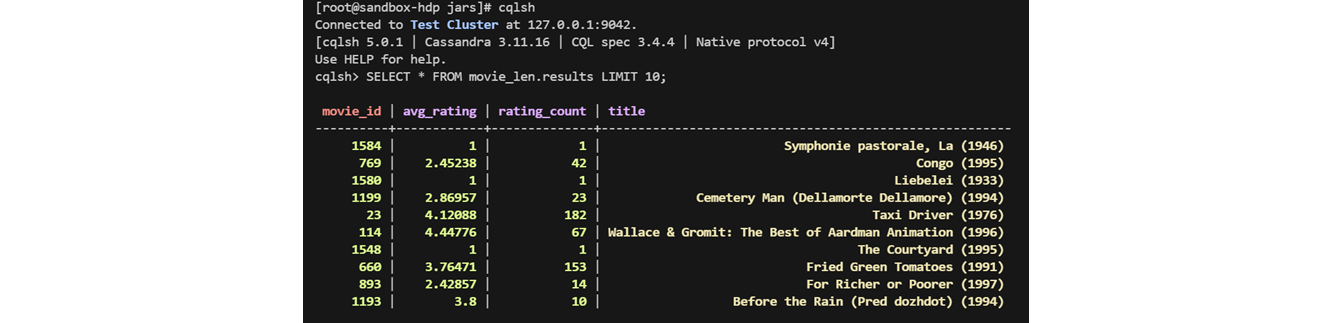

### Data successfully read back from cassandra.

In [15]:
check = spark.read \
    .format("org.apache.spark.sql.cassandra") \
    .options(table="results", keyspace="movie_len") \
    .load()

print("Top 10")
check.orderBy("avg_rating", ascending=False).show(10)
print("Total rows:", check.count())


Top 10
+--------+----------+------------+--------------------+
|movie_id|avg_rating|rating_count|               title|
+--------+----------+------------+--------------------+
|    1189|       5.0|           3|  Prefontaine (1997)|
|    1467|       5.0|           2|Saint of Fort Was...|
|    1500|       5.0|           2|Santa with Muscle...|
|     814|       5.0|           1|Great Day in Harl...|
|    1293|       5.0|           3|     Star Kid (1997)|
|    1201|       5.0|           1|Marlene Dietrich:...|
|    1599|       5.0|           1|Someone Else's Am...|
|    1653|       5.0|           1|Entertaining Ange...|
|    1122|       5.0|           1|They Made Me a Cr...|
|    1536|       5.0|           1|Aiqing wansui (1994)|
+--------+----------+------------+--------------------+
only showing top 10 rows

('Total rows:', 1682)


In [12]:
!pip install matplotlib

DEPRECATION: Python 2.7 reached the end of its life on January 1st, 2020. Please upgrade your Python as Python 2.7 is no longer maintained. pip 21.0 will drop support for Python 2.7 in January 2021. More details about Python 2 support in pip can be found at https://pip.pypa.io/en/latest/development/release-process/#python-2-support pip 21.0 will remove support for this functionality.
     |████████████████████████████████| 12.8 MB 4.1 kB/s eta 0:00:01:00:10██                    | 4.8 MB 928 kB/s eta 0:00:09        | 5.2 MB 928 kB/s eta 0:00:09�███▏               | 6.5 MB 7.2 MB/s eta 0:00:01��█████████             | 7.6 MB 7.2 MB/s eta 0:00:01███████████████████████▉      | 10.3 MB 236 kB/s eta 0:00:11�▍    | 11.0 MB 236 kB/s eta 0:00:088 MB/s eta 0:00:01
     |████████████████████████████████| 93 kB 178 kB/s eta 0:00:01
     |████████████████████████████████| 17.0 MB 26 kB/s  eta 0:00:011B 10.1 MB/s eta 0:00:01 |██████████████████████████████▎ | 16.1 MB 389 kB/s eta 0:00:03
     |████

### Visualization of Top 10 Movies

Horizontal bar chart base on rating count

In [16]:
import matplotlib.pyplot as plt
#collect data from spark
top10 = result2.collect()

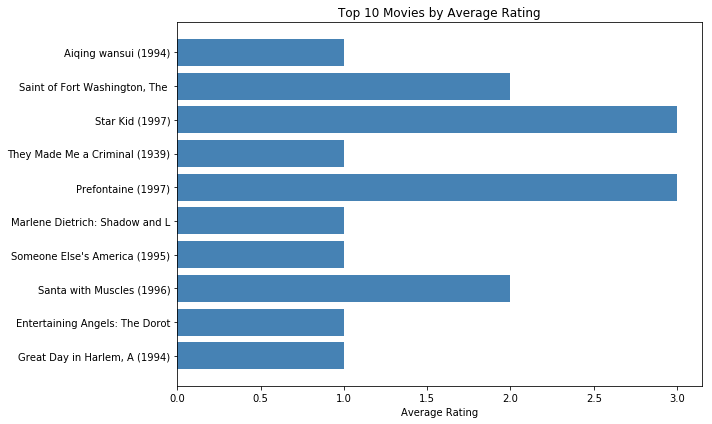

In [17]:

ttl = [row.title[:30] for row in top10]
rc = [row.rating_count for row in top10]

plt.figure(figsize=(10, 6))
plt.barh(ttl, rc, color="steelblue")
plt.xlabel("Average Rating")
plt.title("Top 10 Movies by Average Rating")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
